Logit lens on xLSTM-7B

Notes:
    - 33 hidden states -> Embeddings output + 32 blocks 
    

In [ ]:
from pprint import pprint
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
import torch

xlstm_config = AutoConfig.from_pretrained("NX-AI/xLSTM-7b")
xlstm_config.step_kernel = "native"
xlstm_config.chunkwise_kernel = "chunkwise--native_autograd"
xlstm_config.sequence_kernel = "native_sequence__native"

model = AutoModelForCausalLM.from_pretrained("NX-AI/xLSTM-7b",
                                             config=xlstm_config, device_map="auto")

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("NX-AI/xLSTM-7b")

# Your prompt
prompt = "\n\nQ:Who is Albert Einstein?\n\nA:"

# Tokenize and send to the same device as the model
inputs = tokenizer(prompt, return_tensors="pt")['input_ids'].to(model.device)

# Get the BOS token ID from the tokenizer
bos_id = tokenizer.bos_token_id

# Prepend BOS
bos_tensor = torch.tensor([[bos_id]], device=model.device, dtype=inputs.dtype)
tokens_with_bos = torch.cat([bos_tensor, inputs], dim=1)


outputs = model.generate(
    tokens_with_bos,
    max_new_tokens=30,
    temperature=1.0,    
    do_sample=False
)

# Decode and print
print(tokenizer.decode(outputs[0]))


Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.


<|endoftext|>

Q:Who is Albert Einstein?

A: Albert Einstein was a German-born theoretical physicist who developed the general theory of relativity, one of the two pillars of modern physics (alongside quantum mechanics


: 

In [ ]:
# QA - DONE
FINAL_NORM = model.backbone.out_norm
LM_HEAD = model.lm_head
INPUT_TOKENS = [tokenizer.decode(t).replace("Ġ", "").replace(" ", "") for t in tokenizer(prompt)['input_ids']]

In [6]:
state=hidden_states[20]
logits = LM_HEAD(FINAL_NORM(state))

final_token_logits = logits[0, -1, :]
# Grab the index with the highest number
best_guess_id = torch.argmax(final_token_logits, dim=-1)
print(tokenizer.decode(best_guess_id))

)[$


We extract the hidden state produced by the embedding layer and by all the xlstm blocks. We apply the normalization layer from the pretrained model then pass it through the language modelling head that maps the hidden state vector into the vocabulary space, resulting in the so called logits. Going further, the logits are turned into a probability distribution by the softmax function, then apply the argmax function to this distribution to finally obtain the token prediction. The purpose of this experiment is to see how the quality of the hidden state evolves after each layer and how the confidence in the prediction evolves.  

In [ ]:
# QA - DONE

def extract_top_tokens(lm_head, final_norm, hidden_states, every_other_hidden=True):
    import torch.nn.functional as F
    
    all_layers_predictions = []
    all_layers_logits = []
    indices = []
    for i, h in enumerate(hidden_states):

        if every_other_hidden and i % 2 and i != 0: 
            continue
        
        indices.append(i)
        logits = lm_head(final_norm(hidden_states[i]))
        final_token_logits = logits[0, :-1, :]

        probs = F.softmax(final_token_logits, dim=-1)
        max_logits, best_guess_ids = torch.max(probs, dim=-1)
        layer_tokens = [tokenizer.decode(token_id) for token_id in best_guess_ids]

        all_layers_predictions.append(layer_tokens)
        all_layers_logits.append(max_logits.tolist())

    return all_layers_predictions, all_layers_logits, indices

top_token_per_block, top_logits_per_block, layer_idx = extract_top_tokens(LM_HEAD, FINAL_NORM, hidden_states)


In [24]:
print(layer_idx)

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32]


In [18]:
tokens_with_bos

tensor([[    0,   510,  3158,  8516, 30013, 27287,   689,   253, 22658,  4370,
            15]], device='cuda:0')

In [ ]:
# QA - Done
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_table(top_tokens, top_logits, layer_idx, every_other_hidden=True): 
    num_cols = tokens_with_bos.size()[1] - 1

        
    top_headers = INPUT_TOKENS[:num_cols]
    bottom_headers = (["<BOS>"] + INPUT_TOKENS)[:num_cols]
    
    table_data = [row[:num_cols] for row in top_tokens[::-1]] + [bottom_headers]
    logits_data = [row[:num_cols] for row in top_logits[::-1]]
    all_logits = [val for row in logits_data for val in row]
    norm = mcolors.Normalize(vmin=min(all_logits), vmax=max(all_logits))
    
    import numpy as np
    from matplotlib.colors import ListedColormap
    
    base_cmap = plt.get_cmap('plasma')
    cmap_colors = base_cmap(np.arange(base_cmap.N))
    cmap_colors[:, -1] = 0.75 # Adjust this value (0.0 to 1.0) to change opacity
    cmap = ListedColormap(cmap_colors)
    row_headers = [f"h_{i:02d}" for i in layer_idx][::-1] + ["Input"]
    
    fig, ax = plt.subplots(figsize=(len(top_headers) * 1.2, len(table_data) * 0.5))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(
        cellText=table_data,
        rowLabels=row_headers,
        colLabels=top_headers,
        loc='center',
        cellLoc='center'
    )
    table.scale(1, 1.8)
    
    for (row, col), cell in table.get_celld().items():
        if row == 0 or row == len(table_data) or col == -1: 
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f0f0f0') 
        else:
            val = logits_data[row-1][col]
            r, g, b, a = cmap(norm(val))
            cell.set_facecolor((r, g, b, a))
            if 0.299*r + 0.587*g + 0.114*b < 0.5:
                cell.get_text().set_color('white')
            
            if col < len(top_headers):
                pred_token = str(table_data[row-1][col]).replace("Ġ", "").replace(" ", "")
                target_token = str(top_headers[col]).replace("Ġ", "").replace(" ", "")
                if pred_token == target_token:
                    cell.set_edgecolor('black')
                    cell.set_linewidth(3)
                    cell.set_zorder(10)
                    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.04)
    cbar.set_label('Confidence (Probability)')
    plt.savefig("./top_token_prob_per_inner.png")
    plt.show()



Table <> displays token predictions after each layer at each timestamp. Each column has the token at time t at the bottom and the ground truth next token at the top. The values in-between represent the top token prediction on the hidden state produced by each xlstm block. The colors highlight the confidence in the prediction, with colder colors representing the low confidence predictions(high entropy), whereas the lighter ones represent the more confident predictions. There are instances where the predictions from inner blocks matches the ground truth predictions. These cells are boarded with with thick edges. 

C:\Users\flavi\AppData\Local\Temp\ipykernel_5924\1724604807.py:60: UserWarning: Glyph 12400 (\N{HIRAGANA LETTER BA}) missing from font(s) DejaVu Sans.
  plt.savefig("./top_token_prob_per_inner.png")
d:\A_Facultate\Diseration\code\Dissertation-code\logit_lens\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12400 (\N{HIRAGANA LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


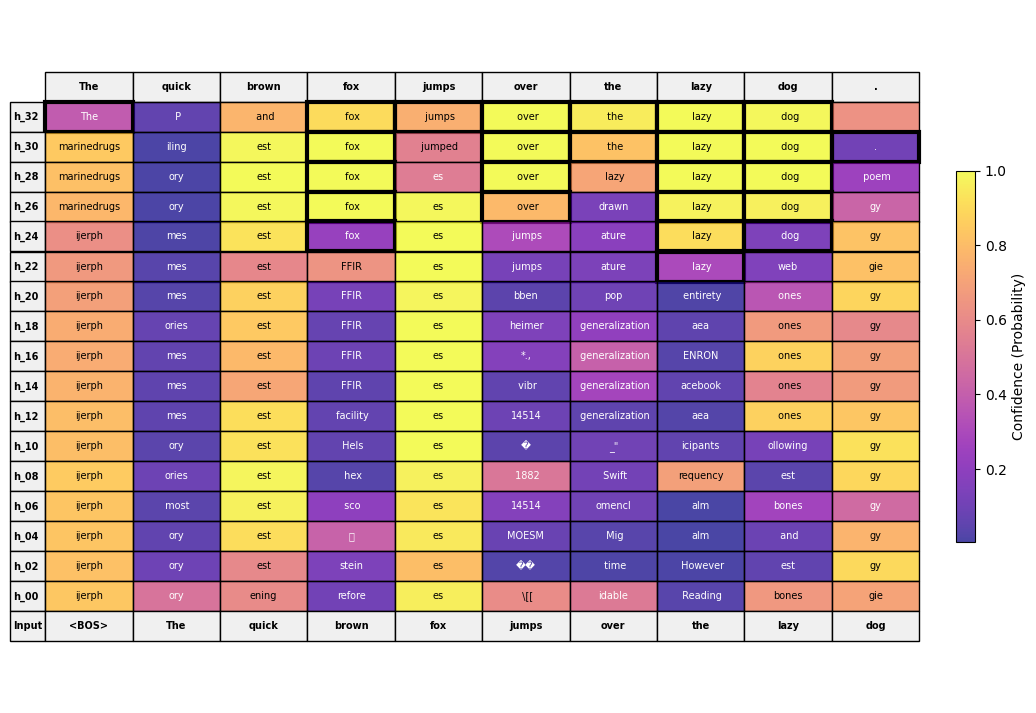

In [26]:
plot_table(top_token_per_block, top_logits_per_block, layer_idx)

The confidence in the prediction is not telling the whole story. In practice language models don't sample using argmax, but rather ranking predicition paths then selecting the best one using beam search algorithm. Given this, we want to find out the rank of our top prediction in the probability distributions. 

In [ ]:
# QA - DONE

from transformers.models import roberta_prelayernorm
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.colors import ListedColormap


def get_top_token_ranking_and_probs(state, lm_head, final_norm):
    logits = lm_head(final_norm(state))
    final_token_logits = logits[0, :-1, :]

    probs = F.softmax(final_token_logits, dim=-1)
    
    sorted_probs, sorted_indices = torch.sort(probs, dim=-1, descending=True)
    
    layer_ranks = []
    layer_probs = []
    
    for pos in range(len(target_ids)):
        target_id = target_ids[pos].item()
        rank = (sorted_indices[pos] == target_id).nonzero(as_tuple=True)[0].item() + 1
        prob = probs[pos, target_id].item()
        
        layer_ranks.append(rank)
        layer_probs.append(prob)
    
    return layer_ranks, layer_probs

def extract_target_ranks_and_probs(lm_head, final_norm, hidden_states, target_ids, every_other_hidden=True):

    all_layers_ranks = []
    all_layers_probs = []
    layer_idx = []
    
    for i, h in enumerate(hidden_states):
        if every_other_hidden and i % 2: 
            continue
        
        layer_idx.append(i)
        state = hidden_states[i]
        layer_ranks, layer_probs = get_top_token_ranking_and_probs(state, lm_head, final_norm)

        all_layers_ranks.append(layer_ranks)
        all_layers_probs.append(layer_probs)

    return all_layers_ranks, all_layers_probs ,layer_idx


Observation: we can see that after each layer the sentence representation improves the understanding of our model. Progressively, the ground-truth prediction climbs the ranks and at the final layer, oftenly appears to be among the top candidates. 

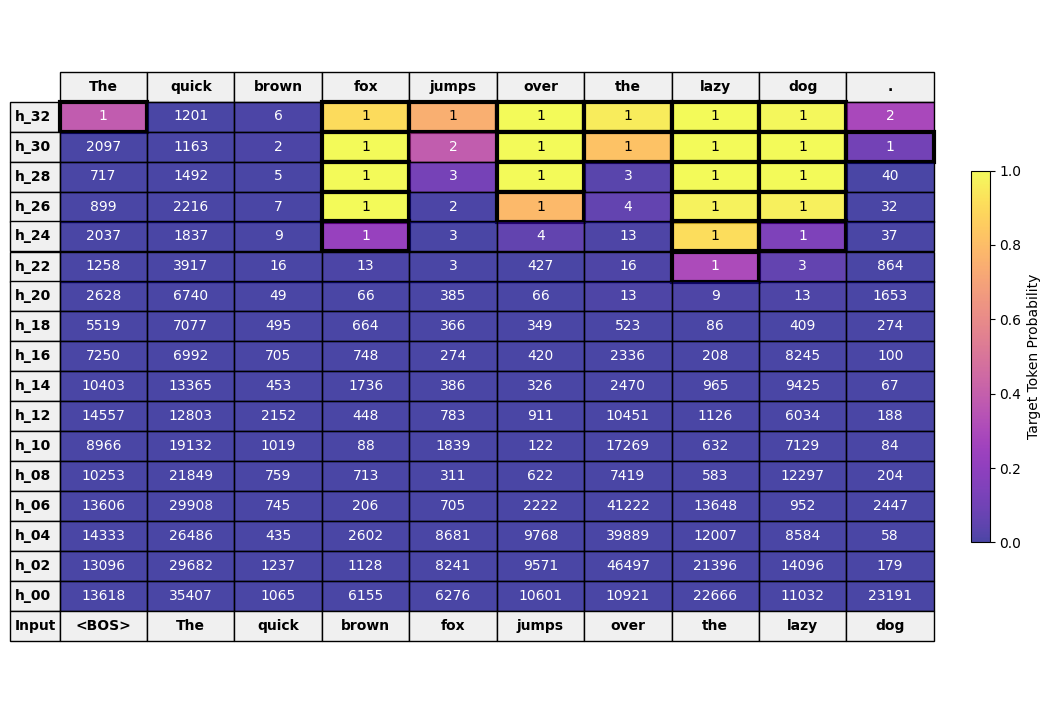

In [33]:
# QA - DONE

def plot_rank_table(ranks_data, probs_data, layer_idx, every_other_hidden=True): 
    if not ranks_data or not ranks_data[0]:
        return
        
    num_cols = tokens_with_bos.size()[1] - 1

        
    top_headers = INPUT_TOKENS[:num_cols]
    bottom_headers = (["<BOS>"] + INPUT_TOKENS)[:num_cols]
    
    table_data = [row[:num_cols] for row in ranks_data[::-1]] + [bottom_headers]
    logits_data = [row[:num_cols] for row in probs_data[::-1]]
    all_logits = [val for row in logits_data for val in row]
    
    norm = mcolors.Normalize(vmin=min(all_logits), vmax=max(all_logits))
    
    base_cmap = plt.get_cmap('plasma')
    cmap_colors = base_cmap(np.arange(base_cmap.N))
    cmap_colors[:, -1] = 0.75
    cmap = ListedColormap(cmap_colors)
    
    row_headers = [f"h_{i:02d}" for i in layer_idx][::-1] + ["Input"]
    
    fig, ax = plt.subplots(figsize=(len(top_headers) * 1.2, len(table_data) * 0.5))
    ax.axis('tight')
    ax.axis('off')
    
    table = ax.table(
        cellText=table_data,
        rowLabels=row_headers,
        colLabels=top_headers,
        loc='center',
        cellLoc='center'
    )
    table.scale(1, 1.8)
    
    for (row, col), cell in table.get_celld().items():
        if row == 0 or row == len(table_data) or col == -1: 
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f0f0f0') 
        else:
            val = logits_data[row-1][col]
            r, g, b, a = cmap(norm(val))
            cell.set_facecolor((r, g, b, a))
            
            if 0.299*r + 0.587*g + 0.114*b < 0.5:
                cell.get_text().set_color('white')
            
            if col < len(top_headers):
                cell_rank = table_data[row-1][col]
                if str(cell_rank) == "1":
                    cell.set_edgecolor('black')
                    cell.set_linewidth(3)
                    cell.set_zorder(10)
                    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.04)
    cbar.set_label('Target Token Probability')
    plt.savefig("./top_token_ranking_per_hidden.png")
    plt.show()

target_ids = inputs[0]
ranks_per_block, probs_per_block, layer_idx = extract_target_ranks_and_probs(LM_HEAD, FINAL_NORM, hidden_states, target_ids)
plot_rank_table(ranks_per_block, probs_per_block, layer_idx)

In [10]:
import numpy as np 

def kl_div(p, q, axis=-1):
  return np.sum(p*np.log(p/q), axis=axis)

In [32]:
def extract_kl_divergences(lm_head, final_norm, hidden_states, every_other_hidden=True):
    import torch.nn.functional as F
    
    final_logits = lm_head(final_norm(hidden_states[-1]))
    final_probs = F.softmax(final_logits[0, :-1, :], dim=-1)
    
    all_layers_kl = []
    layers_idx = []
    for i, h in enumerate(hidden_states):
        if every_other_hidden and i % 2: 
            continue
        
        layers_idx.append(i)
        logits = lm_head(final_norm(hidden_states[i]))
        layer_probs = F.softmax(logits[0, :-1, :], dim=-1)
        
        kl = F.kl_div(layer_probs.log(), final_probs, reduction='none').sum(dim=-1)
        all_layers_kl.append(kl.tolist())
        
    return all_layers_kl, layers_idx

kl_per_block, layers_idx = extract_kl_divergences(LM_HEAD, FINAL_NORM, hidden_states)


C:\Users\flavi\AppData\Local\Temp\ipykernel_5924\3453830263.py:63: UserWarning: Glyph 12400 (\N{HIRAGANA LETTER BA}) missing from font(s) DejaVu Sans.
  plt.savefig("./hidden_vs_outpout_KL.png")
d:\A_Facultate\Diseration\code\Dissertation-code\logit_lens\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12400 (\N{HIRAGANA LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


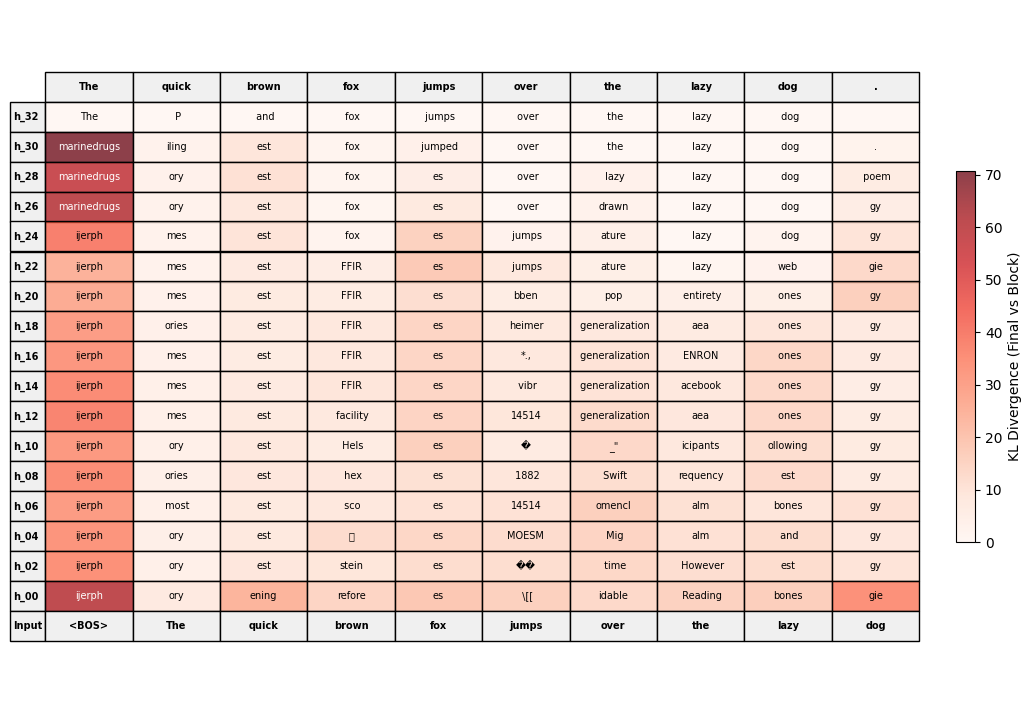

In [34]:
#QA - DONE

def plot_kl_table(top_tokens, kl_data, layer_idx, every_other_hidden=True): 
    if not top_tokens or not top_tokens[0]:
        return
        
    num_cols = tokens_with_bos.size()[1] - 1
        
    top_headers = INPUT_TOKENS[:num_cols]
    bottom_headers = (["<BOS>"] + INPUT_TOKENS)[:num_cols]
    
    table_data = [row[:num_cols] for row in top_tokens[::-1]] + [bottom_headers]
    kl_values = [row[:num_cols] for row in kl_data[::-1]]
    
    all_kl = [val for row in kl_values for val in row]
    
    # We want 0 KL to be bright (similar to high probability), and high KL to be dark
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    import numpy as np
    from matplotlib.colors import ListedColormap
    
    norm = mcolors.Normalize(vmin=min(all_kl), vmax=max(all_kl))
    
    base_cmap = plt.get_cmap('Reds')
    cmap_colors = base_cmap(np.arange(base_cmap.N))
    cmap_colors[:, -1] = 0.75 
    cmap = ListedColormap(cmap_colors)
    
    row_headers = [f"h_{i:02d}" for i in layer_idx][::-1] + ["Input"]
    
    fig, ax = plt.subplots(figsize=(len(top_headers) * 1.2, len(table_data) * 0.5))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(
        cellText=table_data,
        rowLabels=row_headers,
        colLabels=top_headers,
        loc='center',
        cellLoc='center'
    )
    table.scale(1, 1.8)
    
    for (row, col), cell in table.get_celld().items():
        if row == 0 or row == len(table_data) or col == -1: 
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f0f0f0') 
        else:
            val = kl_values[row-1][col]
            r, g, b, a = cmap(norm(val))
            cell.set_facecolor((r, g, b, a))
            if 0.299*r + 0.587*g + 0.114*b < 0.5:
                cell.get_text().set_color('white')
            
            if col < len(top_headers):
                pred_token = str(table_data[row-1][col]).replace("Ġ", "").replace(" ", "")
                target_token = str(top_headers[col]).replace("Ġ", "").replace(" ", "")
                    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.04)
    cbar.set_label('KL Divergence (Final vs Block)')
    plt.savefig("./hidden_vs_outpout_KL.png")
    plt.show()

plot_kl_table(top_token_per_block, kl_per_block, layer_idx)